# 01. Dasar Fuzzy dan Fuzzifikasi

Fuzzy Logic adalah sebuah paradigma komputasional yang bekerja berdasarkan bagaimana manusia berpikir.

Sebagai contoh, bagaimana komputer memahami kalimat "jarak kendaraan sudah dekat"? Sensor memberikan angka, misalnya **3,5 meter**, sedangkan manusia sering memberi petunjuk dengan kata **dekat**, **sedang**, atau **jauh**. 

Fuzzy Logic menghubungkan angka dengan istilah tersebut melalui derajat keanggotaan (membership degree).

![fuzzy logic](img/precission-meaning-fuzzy-logic.png)

## Setup

Jalankan sel ini lebih dahulu. Enam fungsi keanggotaan diperkenalkan di Notebook 01 dan disimpan satu kali pada `membership.py` agar notebook berikutnya memakai implementasi yang sama.

In [2]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi
print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.12.3
Membership module: /home/rynfkn/Ryan/College/Assistant/Modul-Praktikum-KK-RKA-25/Fuzzy Logic/membership.py


---
## 1.1 Mengapa menggunakan Fuzzy Logic?

Pada Crips Logic, sebuah nilai hanya menjadi anggota atau bukan anggota suatu himpunan (hanya bergantung pada nilai true/false). 

Misalnya, aturan praktikum "dekat jika jarak kurang dari 3 meter" memberi nilai 1 untuk 2,99 m dan 0 untuk 3,01 m. Selisih jaraknya kecil, tetapi kategorinya langsung berganti.

Pada Fuzzy Logic, tidak bersifat tegas (true/false), namun dapat berangsur.  

Sebagai contoh, jarak 3,5 m dapat memiliki derajat keanggotaan 0,25 pada istilah "dekat" dan sekitar 0,833 pada istilah "sedang". Nilai jaraknya sendiri tetap pasti, yaitu 3,5 m; yang bertingkat (gradual) adalah tingkat kecocokannya terhadap masing-masing istilah tersebut.

![crips-vs-fuzzy-set](img/Crips-vs-Fuzzy-set.png)

**Derajat keanggotaan bukan probabilitas.** Nilai 0,25 untuk dekat berarti "kecocokan jarak ini dengan definisi dekat adalah 0,25". Itu tidak berarti ada peluang 25% bahwa hasil pengukuran jarak benar. Bentuk dan batas himpunan ditentukan saat merancang model; hasilnya bergantung pada definisi tersebut.

### Contoh penerapan

In [3]:
distances = [2.99, 3.01, 3.5]
display(pd.DataFrame({
    "jarak (m)": distances,
    "crisp dekat: jarak < 3": [int(x < 3) for x in distances],
    "fuzzy dekat: transisi 2-4 m": [linear_down(x, 2, 4) for x in distances],
}))

,jarak (m),crisp dekat: jarak < 3,fuzzy dekat: transisi 2-4 m
0,2.99,1,0.505
1,3.01,0,0.495
2,3.50,0,0.250


Kolom crisp berubah dari 1 ke 0 ketika melewati 3 m. Kolom fuzzy berubah sedikit dari 0,505 menjadi 0,495. Fungsi `linear_down(x, 2, 4)` bernilai penuh sampai 2 m, turun bertahap, dan menjadi nol mulai 4 m. Bagian berikut menjelaskan cara membaca fungsi ini.

---
## 1.2 Variabel, domain, himpunan, dan derajat keanggotaan

| Istilah | Makna | Contoh yang dipakai |
|---|---|---|
| Variabel | Besaran yang diamati | Jarak kendaraan, $x$ |
| Semesta pembicaraan/domain | Rentang nilai yang dibahas | $X=[0,10]$ meter |
| Nilai crisp | Satu hasil pengukuran yang bernilai pasti | $x=3{,}5$ meter |
| Label linguistik | Nama kategori dalam bahasa sehari-hari | Dekat (*small*), sedang (*medium*), jauh (*large*) |
| Himpunan fuzzy $A$ | Kategori beserta derajat keanggotaan setiap nilai domain | Himpunan "dekat" |
| Fungsi keanggotaan $\mu_A$ | Aturan yang memetakan nilai domain ke derajat keanggotaan | $\mu_A:X\to[0,1]$ |
| Derajat keanggotaan $\mu_A(x)$ | Hasil evaluasi fungsi keanggotaan pada satu nilai input | $\mu_{\text{dekat}}(3{,}5)=0{,}25$ |

Pada grafik fungsi keanggotaan, **sumbu horizontal** menyatakan nilai variabel beserta satuannya, sedangkan sumbu vertikal menyatakan derajat keanggotaan yang tidak bersatuan. Derajat keanggotaan bernilai 0 berarti suatu nilai tidak termasuk dalam label tersebut, bernilai 1 berarti sepenuhnya termasuk, dan nilai di antaranya berarti termasuk sebagian.

Satu nilai input dapat menjadi anggota beberapa himpunan fuzzy sekaligus. **Jumlah derajat keanggotaan antarlabel tidak harus sama dengan 1**, karena setiap fungsi keanggotaan menilai kecocokan secara mandiri. Derajat keanggotaan juga tidak perlu dinormalisasi sebelum aturan fuzzy dievaluasi.

### Contoh penerapan

In [4]:
distance = 3.5
mu_distance = {
    "dekat": linear_down(distance, 2, 4),
    "sedang": trapezoidal(distance, 1, 4, 6, 9),
    "jauh": linear_up(distance, 6, 8),
}
display(pd.Series(mu_distance, name="derajat keanggotaan"))
print(f"Jumlah derajat: {sum(mu_distance.values()):.3f}")

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat keanggotaan, dtype: float64

Jumlah derajat: 1.083


Hasilnya $[0{,}25;\ 0{,}8333;\ 0]$ dalam urutan dekat, sedang, jauh. Jumlahnya sekitar 1,0833 dan tetap sah. Vektor ini merangkum keanggotaan **satu input**; fungsi keanggotaan mendefinisikan kategori untuk **seluruh domain**.

## 1.3 Fungsi Keanggotaan Linier: Garis Naik dan Garis Turun

Dalam fuzzy logic, fungsi keanggotaan linier digunakan untuk menggambarkan perubahan derajat keanggotaan secara bertahap dari 0 ke 1 atau sebaliknya. Dua bentuk dasarnya adalah **fungsi linier naik** dan **fungsi linier turun**.

### Fungsi linier naik

Fungsi linier naik digunakan ketika derajat keanggotaan suatu nilai semakin besar seiring dengan bertambahnya nilai input.

$$
\mu_{\uparrow}(x;a,b)=
\begin{cases}
0, & x\leq a,\\[4pt]
\dfrac{x-a}{b-a}, & a<x<b,\\[6pt]
1, & x\geq b.
\end{cases}
$$

Pada fungsi ini:

* jika $x\leq a$, maka derajat keanggotaannya adalah 0;
* jika $a<x<b$, maka derajat keanggotaan meningkat secara linier dari 0 menuju 1;
* jika $x\geq b$, maka derajat keanggotaannya adalah 1.

Nilai

$$
\frac{x-a}{b-a}
$$

menyatakan perbandingan antara **jarak posisi $x$ dari titik awal $a$** dan **panjang keseluruhan daerah transisi dari $a$ sampai $b$**.

---

### Fungsi linier turun

Sebaliknya, fungsi linier turun digunakan ketika derajat keanggotaan semakin kecil seiring dengan bertambahnya nilai input.

$$
\mu_{\downarrow}(x;a,b)=
\begin{cases}
1, & x\leq a,\\[4pt]
\dfrac{b-x}{b-a}, & a<x<b,\\[6pt]
0, & x\geq b.
\end{cases}
$$

Pada fungsi ini:

* jika $x\leq a$, maka derajat keanggotaannya adalah 1;
* jika $a<x<b$, maka derajat keanggotaan menurun secara linier dari 1 menuju 0;
* jika $x\geq b$, maka derajat keanggotaannya adalah 0.

### Contoh

Misalkan variabel **jarak** memiliki himpunan fuzzy **dekat** yang menggunakan fungsi linier turun dari 2 m sampai 4 m. Artinya,

* jarak $\leq 2$ m dianggap sepenuhnya **dekat**, sehingga $\mu_{\text{dekat}}=1$;
* jarak antara 2 m dan 4 m mengalami penurunan derajat keanggotaan;
* jarak $\geq 4$ m tidak lagi dianggap **dekat**, sehingga $\mu_{\text{dekat}}=0$.

Untuk jarak $x=3{,}5$ m, karena nilai tersebut berada di antara 2 m dan 4 m, digunakan bagian linier dari fungsi:

$$
\mu_{\text{dekat}}(3{,}5)
=
\frac{4-3{,}5}{4-2}
=
\frac{0{,}5}{2}
=
0{,}25.
$$

Jadi, jarak 3,5 m memiliki **derajat keanggotaan 0,25 terhadap himpunan fuzzy dekat**. Nilai ini tidak berarti bahwa jarak tersebut memiliki peluang 25% untuk menjadi dekat, melainkan menunjukkan **tingkat kesesuaiannya terhadap konsep “dekat”**.

Sekarang misalkan himpunan fuzzy **jauh** menggunakan fungsi linier naik dari 6 m sampai 8 m:

$$
\mu_{\text{jauh}}(x)=
\begin{cases}
0, & x\leq 6,\\[4pt]
\dfrac{x-6}{8-6}, & 6<x<8,\\[6pt]
1, & x\geq 8.
\end{cases}
$$

Karena $3{,}5 \leq 6$, maka:

$$
\mu_{\text{jauh}}(3{,}5)=0.
$$

Dengan demikian, untuk input jarak 3,5 m diperoleh:

$$
\mu_{\text{dekat}}(3{,}5)=0{,}25,
\qquad
\mu_{\text{jauh}}(3{,}5)=0.
$$

Bentuk fungsi keanggotaan yang memiliki bagian datar dengan nilai keanggotaan 1 pada salah satu sisinya sering disebut **fungsi bahu (shoulder membership function)**.

Saat membaca fungsi keanggotaan berbentuk bertingkat (*piecewise*), langkah yang paling penting adalah **menentukan terlebih dahulu posisi nilai input $x$ terhadap batas $a$ dan $b$**. Setelah itu, gunakan hanya persamaan pada cabang yang sesuai dengan posisi tersebut.


### Contoh penerapan

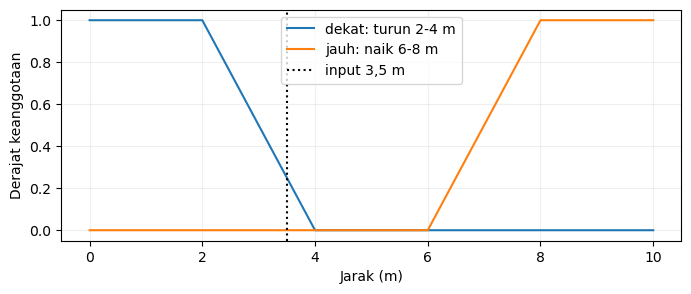

In [5]:
distance_grid = np.linspace(0, 10, 501)
plt.figure(figsize=(8, 3))
plt.plot(distance_grid, [linear_down(x, 2, 4) for x in distance_grid], label="dekat: turun 2-4 m")
plt.plot(distance_grid, [linear_up(x, 6, 8) for x in distance_grid], label="jauh: naik 6-8 m")
plt.axvline(3.5, color="black", linestyle=":", label="input 3,5 m")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Ikuti garis vertikal pada 3,5 m sampai bertemu kurva dekat, lalu baca ketinggiannya: 0,25. Kurva jauh masih berada pada sumbu horizontal, sehingga derajatnya 0.

## 1.4 Fungsi Keanggotaan Segitiga dan Trapesium

Selain fungsi linier naik dan turun, dua bentuk fungsi keanggotaan yang banyak digunakan dalam fuzzy logic adalah **fungsi segitiga** dan **fungsi trapesium**. Keduanya dibentuk dari beberapa garis linier, tetapi memiliki cara yang berbeda dalam menentukan nilai yang dianggap paling mewakili suatu himpunan fuzzy.

### Fungsi keanggotaan segitiga

Fungsi keanggotaan **segitiga** memiliki tiga parameter, yaitu $a$, $b$, dan $c$, dengan:

$$
a<b<c.
$$

Ketiga parameter tersebut memiliki arti:

* $a$ = batas kiri, yaitu titik saat derajat keanggotaan mulai naik dari 0;
* $b$ = titik puncak, yaitu nilai yang memiliki derajat keanggotaan maksimum $\mu(x)=1$;
* $c$ = batas kanan, yaitu titik saat derajat keanggotaan kembali menjadi 0.

Secara matematis, fungsi keanggotaan segitiga dapat dituliskan sebagai:

$$
\mu_{\triangle}(x;a,b,c)=
\begin{cases}
0, & x\leq a,\\[4pt]
\dfrac{x-a}{b-a}, & a<x\leq b,\\[8pt]
\dfrac{c-x}{c-b}, & b<x<c,\\[8pt]
0, & x\geq c.
\end{cases}
$$

atau secara ringkas:

$$
\mu_{\triangle}(x;a,b,c)=
\begin{cases}
0, & x\leq a \text{ atau } x\geq c,\\[4pt]
\dfrac{x-a}{b-a}, & a<x\leq b,\\[8pt]
\dfrac{c-x}{c-b}, & b<x<c.
\end{cases}
$$

Bentuk fungsi ini dapat dipahami dalam tiga bagian. Dari $a$ menuju $b$, derajat keanggotaan **naik secara linier** dari 0 menjadi 1. Pada $x=b$, derajat keanggotaan mencapai nilai maksimum:

$$
\mu(b)=1.
$$

Kemudian, dari $b$ menuju $c$, derajat keanggotaan **turun secara linier** dari 1 menjadi 0.

Dengan demikian, fungsi segitiga memiliki **satu nilai yang dianggap paling mewakili suatu label fuzzy**, yaitu nilai $b$.

Sebagai contoh, misalkan kategori **Sedang** direpresentasikan menggunakan fungsi segitiga:

$$
(1,5,9).
$$

Artinya:

* pada $x=1$, derajat keanggotaan adalah 0;
* dari $x=1$ sampai $x=5$, derajat keanggotaan meningkat;
* pada $x=5$, nilai dianggap sepenuhnya **Sedang**, sehingga $\mu_{\text{sedang}}(5)=1$;
* dari $x=5$ sampai $x=9$, derajat keanggotaan menurun;
* pada $x\geq9$, derajat keanggotaan kembali menjadi 0.

---

### Fungsi keanggotaan trapesium

Fungsi keanggotaan **trapesium** merupakan pengembangan dari fungsi segitiga. Perbedaannya adalah fungsi trapesium tidak hanya memiliki satu titik dengan derajat keanggotaan 1, tetapi memiliki **sebuah rentang nilai yang seluruhnya dianggap sepenuhnya memenuhi suatu label fuzzy**.

Fungsi ini memiliki empat parameter:

$$
a<b\leq c<d.
$$

Parameter tersebut memiliki arti:

* $a$ = batas kiri saat derajat keanggotaan mulai naik dari 0;
* $b$ = titik awal derajat keanggotaan penuh;
* $c$ = titik akhir derajat keanggotaan penuh;
* $d$ = batas kanan saat derajat keanggotaan kembali menjadi 0.

Fungsi keanggotaan trapesium dituliskan sebagai:

$$
\mu_{\text{trap}}(x;a,b,c,d)=
\begin{cases}
0, & x\leq a,\\[4pt]
\dfrac{x-a}{b-a}, & a<x<b,\\[8pt]
1, & b\leq x\leq c,\\[4pt]
\dfrac{d-x}{d-c}, & c<x<d,\\[8pt]
0, & x\geq d.
\end{cases}
$$

atau secara ringkas:

$$
\mu_{\text{trap}}(x;a,b,c,d)=
\begin{cases}
0, & x\leq a \text{ atau } x\geq d,\\[4pt]
\dfrac{x-a}{b-a}, & a<x<b,\\[8pt]
1, & b\leq x\leq c,\\[4pt]
\dfrac{d-x}{d-c}, & c<x<d.
\end{cases}
$$

Fungsi tersebut mempunyai tiga bagian utama:

1. **Daerah naik**, yaitu dari $a$ sampai $b$, ketika derajat keanggotaan meningkat dari 0 menuju 1.
2. **Daerah penuh**, yaitu dari $b$ sampai $c$, ketika semua nilai mempunyai derajat keanggotaan 1.
3. **Daerah turun**, yaitu dari $c$ sampai $d$, ketika derajat keanggotaan menurun dari 1 menuju 0.

### Contoh perhitungan fungsi trapesium

Misalkan kategori jarak **Sedang** direpresentasikan menggunakan fungsi trapesium:

$$
(1,4,6,9).
$$

Maka:

* $x\leq1$ memiliki derajat keanggotaan 0;
* $1<x<4$ merupakan daerah transisi naik;
* $4\leq x\leq6$ merupakan daerah keanggotaan penuh dengan $\mu(x)=1$;
* $6<x<9$ merupakan daerah transisi turun;
* $x\geq9$ memiliki derajat keanggotaan 0.

Dengan demikian, rentang **4–6 meter** dianggap sepenuhnya memenuhi kategori **Sedang**.

Sekarang misalkan jarak yang diamati adalah:

$$
x=3{,}5.
$$

Langkah pertama adalah menentukan posisi $x$. Karena:

$$
1<3{,}5<4,
$$

maka $x=3{,}5$ berada pada **sisi naik** fungsi trapesium. Oleh karena itu, digunakan persamaan:

$$
\mu_{\text{sedang}}(x)
=
\frac{x-a}{b-a}.
$$

Substitusikan $a=1$, $b=4$, dan $x=3{,}5$:

$$
\mu_{\text{sedang}}(3{,}5)
=
\frac{3{,}5-1}{4-1}
=
\frac{2{,}5}{3}
\approx0{,}8333.
$$

Jadi:

$$
\boxed{\mu_{\text{sedang}}(3{,}5)\approx0{,}8333}
$$

Artinya, jarak 3,5 meter memiliki **derajat keanggotaan sekitar 0,83 terhadap kategori Sedang**. Nilai tersebut sudah cukup dekat dengan daerah keanggotaan penuh yang dimulai pada 4 meter.

### Perbedaan segitiga dan trapesium

Perbedaan utama kedua fungsi tersebut terletak pada daerah dengan derajat keanggotaan maksimum.

Pada fungsi **segitiga**, hanya terdapat satu titik yang mempunyai derajat keanggotaan 1:

$$
\mu(b)=1.
$$

Sementara itu, pada fungsi **trapesium**, terdapat sebuah rentang nilai yang memiliki derajat keanggotaan 1:

$$
\mu(x)=1,\qquad b\leq x\leq c.
$$

Oleh karena itu, fungsi segitiga cocok ketika terdapat **satu nilai yang paling mewakili suatu kategori**, sedangkan fungsi trapesium cocok ketika terdapat **rentang nilai yang sama-sama dianggap sepenuhnya mewakili kategori tersebut**.

Dalam contoh jarak di atas, fungsi **Sedang** yang digunakan adalah trapesium $(1,4,6,9)$. Fungsi segitiga $(1,5,9)$ dapat digunakan sebagai bentuk alternatif untuk memahami perbedaannya, tetapi **bukan fungsi keanggotaan Sedang yang digunakan pada contoh tersebut**.

Hal terpenting ketika menghitung fungsi segitiga maupun trapesium adalah selalu menentukan terlebih dahulu **posisi nilai input $x$ terhadap parameter-parameter fungsi**. Setelah mengetahui posisi tersebut, pilih hanya bagian persamaan yang sesuai.


### Contoh penerapan

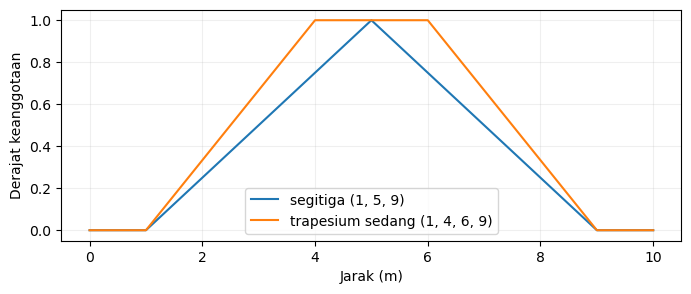

,jarak (m),segitiga,trapesium
0,1.0,0.000,0.000000
1,3.5,0.625,0.833333
2,4.0,0.750,1.000000
3,5.0,1.000,1.000000
4,6.0,0.750,1.000000
5,9.0,0.000,0.000000


In [5]:
plt.figure(figsize=(8, 3))
plt.plot(distance_grid, [triangular(x, 1, 5, 9) for x in distance_grid], label="segitiga (1, 5, 9)")
plt.plot(distance_grid, [trapezoidal(x, 1, 4, 6, 9) for x in distance_grid], label="trapesium sedang (1, 4, 6, 9)")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
display(pd.DataFrame([
    {"jarak (m)": x, "segitiga": triangular(x, 1, 5, 9),
     "trapesium": trapezoidal(x, 1, 4, 6, 9)}
    for x in [1, 3.5, 4, 5, 6, 9]
]))

Pada 4 dan 6 m, trapesium bernilai 1, sedangkan segitiga bernilai 0,75. Memilih bentuk fungsi berarti memilih definisi label. Titik patah perlu ditentukan dari pengetahuan masalah atau data, kemudian diuji kesesuaiannya.

---
## 1.5 Pengayaan: kurva S dan phi

**Kurva S** pada modul ini adalah fungsi kuadratik bertingkat yang dinamai `sigmoid`, dengan $b=(a+c)/2$. Derajat berubah dari 0 menuju 1 dan bernilai 0,5 di titik tengah $b$.

$$S(x;a,b,c)=\begin{cases}0,&x\le a\\2\left(\frac{x-a}{c-a}\right)^2,&a<x\le b\\1-2\left(\frac{c-x}{c-a}\right)^2,&b<x<c\\1,&x\ge c.\end{cases}$$

**Phi** membentuk lonceng: naik halus menuju satu puncak, lalu turun halus. Dalam `phi(x, a, b, c)`, parameter $a$ berarti tepi kiri, $b$ puncak, dan $c$ tepi kanan:

$$\mu_{\phi}(x;a,b,c)=\begin{cases}S\left(x;a,\frac{a+b}{2},b\right),&x\le b\\1-S\left(x;b,\frac{b+c}{2},c\right),&x>b.\end{cases}$$

Catatan sumber: parameter phi pada halaman 29 memakai pusat dan lebar dengan notasi berbeda. Cabang kanan yang tercetak juga belum memakai komplemen; di sini digunakan $1-S$ agar sisi kanan menurun sesuai gambar lonceng. Kurva S ini berbeda rumus dari fungsi logistik, dan phi ini bukan fungsi Gaussian yang juga diperlihatkan pada halaman 22.

### Contoh penerapan

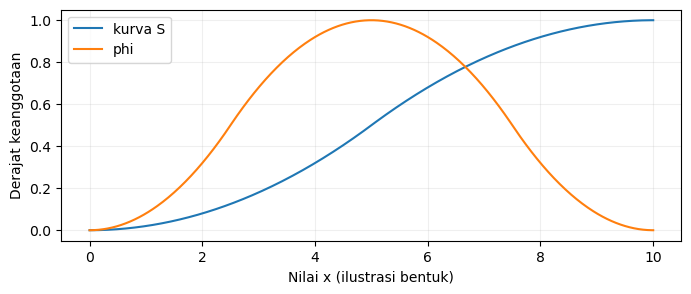

S pada 0, 5, 10: [0.0, 0.5, 1.0]
Phi pada 0, 5, 10: [0.0, 1.0, 0.0]


In [6]:
plt.figure(figsize=(8, 3))
plt.plot(distance_grid, [sigmoid(x, 0, 5, 10) for x in distance_grid], label="kurva S")
plt.plot(distance_grid, [phi(x, 0, 5, 10) for x in distance_grid], label="phi")
plt.xlabel("Nilai x (ilustrasi bentuk)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
print("S pada 0, 5, 10:", [sigmoid(x, 0, 5, 10) for x in (0, 5, 10)])
print("Phi pada 0, 5, 10:", [phi(x, 0, 5, 10) for x in (0, 5, 10)])

Kurva S memberi [0; 0,5; 1], sedangkan phi memberi [0; 1; 0]. Keenam fungsi yang sudah digunakan tersedia di `membership.py`: `linear_up`, `linear_down`, `triangular`, `trapezoidal`, `sigmoid`, dan `phi`. Setiap pemanggilan menerima satu nilai input dan mengembalikan satu derajat antara 0 dan 1.

## 1.6 Fuzzifikasi: Dari Nilai Crisp Menjadi Derajat Keanggotaan

**Fuzzifikasi** (*fuzzification*) adalah proses mengubah sebuah nilai input yang bersifat **crisp** menjadi satu atau lebih **derajat keanggotaan fuzzy**.

Nilai **crisp** adalah nilai pengukuran yang pasti, misalnya:

$$
x=3{,}5\text{ meter}.
$$

Dalam sistem fuzzy, nilai tersebut tidak langsung dimasukkan ke dalam satu kategori saja. Sebaliknya, sistem menghitung seberapa kuat nilai tersebut menjadi anggota dari setiap himpunan fuzzy yang telah didefinisikan, misalnya **Dekat**, **Sedang**, dan **Jauh**.

Dengan demikian, fuzzifikasi dapat dipandang sebagai proses:

$$
\boxed{
\text{nilai crisp}
\longrightarrow
\text{sekumpulan derajat keanggotaan}
}
$$

Secara umum, fuzzifikasi dilakukan melalui beberapa langkah:

1. menentukan **variabel input** dan domain nilainya;
2. menentukan **himpunan fuzzy atau label linguistik** untuk variabel tersebut;
3. menentukan **fungsi keanggotaan** untuk setiap label;
4. memasukkan nilai crisp hasil pengukuran ke setiap fungsi keanggotaan;
5. menyimpan seluruh derajat keanggotaan yang dihasilkan untuk digunakan pada tahap inferensi fuzzy.

### Contoh fuzzifikasi variabel jarak

Misalkan variabel **Jarak** memiliki tiga label linguistik:

* **Dekat** (*small*),
* **Sedang** (*medium*),
* **Jauh** (*large*).

Fungsi keanggotaan yang digunakan adalah sebagai berikut:

| Label             | Fungsi                       | Interpretasi                                                              |
| ----------------- | ---------------------------- | ------------------------------------------------------------------------- |
| Dekat / *small*   | `linear_down(x, 2, 4)`       | Keanggotaan penuh hingga 2 m, kemudian menurun, dan menjadi 0 mulai 4 m   |
| Sedang / *medium* | `trapezoidal(x, 1, 4, 6, 9)` | Naik pada 1–4 m, penuh pada 4–6 m, kemudian turun pada 6–9 m              |
| Jauh / *large*    | `linear_up(x, 6, 8)`         | Keanggotaan 0 hingga 6 m, kemudian meningkat, dan menjadi penuh mulai 8 m |

Misalkan diperoleh hasil pengukuran:

$$
x=3{,}5\text{ m}.
$$

Nilai tersebut kemudian dimasukkan ke **setiap fungsi keanggotaan**.

#### 1. Derajat keanggotaan Dekat

Untuk kategori **Dekat**, digunakan fungsi linier turun dari 2 m sampai 4 m. Karena:

$$
2<3{,}5<4,
$$

maka:

$$
\mu_{\text{dekat}}(3{,}5)
=
\frac{4-3{,}5}{4-2}
=
\frac{0{,}5}{2}
=
0{,}25.
$$

Jadi:

$$
\mu_{\text{dekat}}(3{,}5)=0{,}25.
$$

#### 2. Derajat keanggotaan Sedang

Kategori **Sedang** menggunakan fungsi trapesium:

$$
(1,4,6,9).
$$

Karena:

$$
1<3{,}5<4,
$$

nilai tersebut berada pada bagian naik fungsi trapesium. Maka:

$$
\mu_{\text{sedang}}(3{,}5)
=
\frac{3{,}5-1}{4-1}
=
\frac{2{,}5}{3}
\approx0{,}8333.
$$

Jadi:

$$
\mu_{\text{sedang}}(3{,}5)\approx0{,}8333.
$$

#### 3. Derajat keanggotaan Jauh

Kategori **Jauh** mulai mengalami kenaikan keanggotaan pada 6 m. Karena:

$$
3{,}5<6,
$$

maka:

$$
\mu_{\text{jauh}}(3{,}5)=0.
$$

### Hasil fuzzifikasi

Seluruh hasil tersebut dapat disusun sebagai sebuah vektor derajat keanggotaan:

$$
\boldsymbol{\mu}(3{,}5)
=
[
\mu_{\text{dekat}}(3{,}5),
\mu_{\text{sedang}}(3{,}5),
\mu_{\text{jauh}}(3{,}5)
].
$$

Sehingga:

$$
\boxed{
\boldsymbol{\mu}(3{,}5)
=
[0{,}25,\;0{,}8333,\;0]
}
$$

Hasil tersebut dapat dibaca sebagai:

* jarak 3,5 m memiliki derajat keanggotaan **0,25 sebagai Dekat**;
* jarak 3,5 m memiliki derajat keanggotaan **0,8333 sebagai Sedang**;
* jarak 3,5 m memiliki derajat keanggotaan **0 sebagai Jauh**.

![Fuzzifikasi jarak pada halaman 24 Fuzzy Logic complete.pdf](img/complete-24-fuzzifikasi.png)


### Contoh penerapan

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat pada 3,5 m, dtype: float64

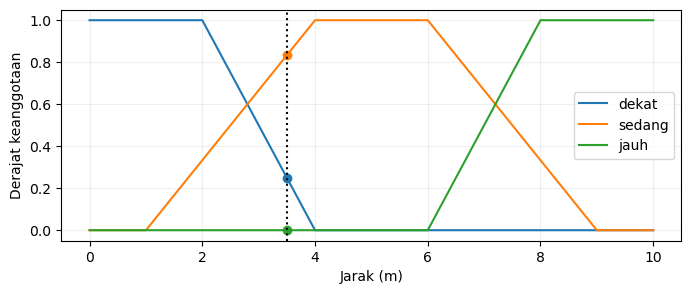

In [6]:
def fuzzify_distance(distance):
    """Hitung derajat jarak pada domain praktikum 0 sampai 10 meter."""
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

mu_distance = fuzzify_distance(3.5)
display(pd.Series(mu_distance, name="derajat pada 3,5 m"))
plt.figure(figsize=(8, 3))
for label in mu_distance:
    plt.plot(distance_grid, [fuzzify_distance(x)[label] for x in distance_grid], label=label)
    plt.scatter([3.5], [mu_distance[label]])
plt.axvline(3.5, color="black", linestyle=":")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 1.7 Basis Pengetahuan dan Operator Aturan

Setelah proses **fuzzifikasi**, derajat keanggotaan yang diperoleh digunakan untuk mengevaluasi sekumpulan aturan fuzzy. Kumpulan aturan ini merupakan bagian dari **basis pengetahuan** (*knowledge base*) pada sistem fuzzy.

Aturan fuzzy umumnya ditulis dalam bentuk:

$$
\text{IF kondisi THEN aksi}
$$

Bagian setelah **IF** disebut **anteseden** (*antecedent*), sedangkan bagian setelah **THEN** disebut **konsekuen** (*consequent*).

Sebagai contoh, digunakan tiga aturan berikut:

| Aturan | Anteseden       | Konsekuen             |
| ------ | --------------- | --------------------- |
| R1     | IF jarak Dekat  | THEN kecepatan Rendah |
| R2     | IF jarak Sedang | THEN kecepatan Sedang |
| R3     | IF jarak Jauh   | THEN kecepatan Tinggi |

Aturan R1 dapat dibaca:

> Jika jarak termasuk kategori **Dekat**, maka kecepatan seharusnya **Rendah**.

Dalam fuzzy logic, suatu aturan tidak hanya berada dalam keadaan **aktif** atau **tidak aktif**. Setiap aturan dapat aktif dengan tingkat tertentu, sesuai dengan derajat kebenaran antesedennya.

### Kekuatan aktivasi aturan

Tingkat aktivasi sebuah aturan disebut **kekuatan aktivasi** atau *firing strength*, yang biasanya dilambangkan dengan:

$$
\alpha_i.
$$

Nilai $\alpha_i$ berada pada rentang:

$$
0\leq\alpha_i\leq1.
$$

Semakin besar nilai $\alpha_i$, semakin kuat aturan tersebut diaktifkan oleh input yang diberikan.

Dari proses fuzzifikasi sebelumnya untuk:

$$
x=3{,}5\text{ m},
$$

diperoleh:

$$
\mu_{\text{dekat}}=0{,}25,
$$

$$
\mu_{\text{sedang}}=0{,}8333,
$$

dan

$$
\mu_{\text{jauh}}=0.
$$

Karena ketiga aturan di atas masing-masing hanya memiliki **satu kondisi pada anteseden**, kekuatan aktivasinya langsung sama dengan derajat keanggotaan input yang bersesuaian.

Untuk R1:

$$
\alpha_1
=
\mu_{\text{dekat}}(3{,}5)
=
0{,}25.
$$

Untuk R2:

$$
\alpha_2
=
\mu_{\text{sedang}}(3{,}5)
=
0{,}8333.
$$

Untuk R3:

$$
\alpha_3
=
\mu_{\text{jauh}}(3{,}5)
=
0.
$$

Sehingga:

$$
\boxed{
\alpha_1=0{,}25,\qquad
\alpha_2=0{,}8333,\qquad
\alpha_3=0
}
$$

Artinya, aturan R2 paling kuat diaktifkan, tetapi aturan R1 juga masih aktif dengan tingkat yang lebih rendah. Sementara itu, R3 tidak aktif karena derajat keanggotaan **Jauh** bernilai 0.

Perlu diperhatikan bahwa sistem fuzzy tetap mempertahankan semua aturan yang memiliki nilai aktivasi bukan nol. Dengan demikian, beberapa aturan dapat aktif secara bersamaan.

---

### Aturan dengan beberapa kondisi

Dalam sistem yang lebih kompleks, sebuah aturan dapat memiliki lebih dari satu kondisi.

Contohnya:

$$
\text{IF jarak Dekat AND kecepatan Tinggi THEN rem Kuat}.
$$

Misalkan diperoleh:

$$
\mu_{\text{dekat}}=0{,}25
$$

dan

$$
\mu_{\text{tinggi}}=0{,}8.
$$

Untuk menggabungkan beberapa kondisi tersebut, digunakan **operator fuzzy**. Operator yang umum digunakan adalah **AND**, **OR**, dan **NOT**.

### Operator AND

Operator **AND** digunakan ketika semua kondisi dalam anteseden harus dipertimbangkan secara bersama-sama.

Salah satu operator yang paling umum digunakan adalah fungsi minimum:

$$
\mu_{A\cap B}
=
\min(\mu_A,\mu_B).
$$

Untuk:

$$
\mu_A=0{,}25
$$

dan

$$
\mu_B=0{,}8,
$$

maka:

$$
\mu_{A\cap B}
=
\min(0{,}25,0{,}8)
=
0{,}25.
$$

Sehingga kekuatan aktivasi aturan menjadi:

$$
\boxed{\alpha=0{,}25}
$$

Intuisinya, sebuah aturan dengan operator AND dibatasi oleh **kondisi yang paling lemah**.

Sebagai contoh:

$$
\text{IF jarak Dekat AND kecepatan Tinggi}
$$

hanya dapat aktif sebesar 0,25 meskipun kondisi **kecepatan Tinggi** memiliki derajat 0,8, karena kondisi **jarak Dekat** hanya terpenuhi sebesar 0,25.

---

### Operator OR

Operator **OR** digunakan ketika cukup salah satu kondisi terpenuhi untuk mengaktifkan aturan.

Operator yang umum digunakan adalah fungsi maksimum:

$$
\mu_{A\cup B}
=
\max(\mu_A,\mu_B).
$$

Untuk:

$$
\mu_A=0{,}25
$$

dan

$$
\mu_B=0{,}8,
$$

maka:

$$
\mu_{A\cup B}
=
\max(0{,}25,0{,}8)
=
0{,}8.
$$

Sehingga:

$$
\boxed{\alpha=0{,}8}
$$

Intuisinya, pada operator OR, kondisi dengan derajat keanggotaan terbesar sudah cukup untuk memberikan aktivasi yang kuat.

---

### Operator NOT

Operator **NOT** digunakan untuk menyatakan negasi atau kebalikan dari sebuah kondisi fuzzy.

Operator komplemen yang umum digunakan adalah:

$$
\mu_{\neg A}=1-\mu_A.
$$

Jika:

$$
\mu_A=0{,}25,
$$

maka:

$$
\mu_{\neg A}
=
1-0{,}25
=
0{,}75.
$$

Sehingga:

$$
\boxed{\mu_{\text{NOT }A}=0{,}75}
$$

Artinya, apabila suatu nilai memiliki derajat keanggotaan 0,25 terhadap himpunan $A$, maka derajat keanggotaannya terhadap **NOT A** adalah 0,75.

---

### Ringkasan operator fuzzy

Operator yang digunakan dapat dirangkum sebagai berikut:

| Operator | Operasi             | Contoh untuk 0,25 dan 0,8 | Interpretasi                                     |
| -------- | ------------------- | ------------------------: | ------------------------------------------------ |
| AND      | $\min(\mu_A,\mu_B)$ |                  $0{,}25$ | Dibatasi oleh kondisi yang paling lemah          |
| OR       | $\max(\mu_A,\mu_B)$ |                   $0{,}8$ | Cukup salah satu kondisi memiliki derajat tinggi |
| NOT      | $1-\mu_A$           |                  $0{,}75$ | Menghasilkan derajat komplemen                   |

Operator **min**, **max**, dan **komplemen** di atas merupakan pilihan yang sangat umum pada sistem fuzzy, khususnya pada inferensi Mamdani. Namun, operator fuzzy tidak terbatas pada bentuk tersebut. Dalam sistem tertentu, AND misalnya dapat menggunakan perkalian (*product*) dan OR dapat menggunakan operator lain sesuai desain sistem.

Hal utama yang perlu dipahami adalah bahwa **fuzzifikasi menghasilkan derajat keanggotaan**, sedangkan **evaluasi aturan menggunakan derajat tersebut untuk menentukan kekuatan aktivasi setiap aturan**.

Alur prosesnya dapat diringkas sebagai:

$$
\boxed{
\text{Input crisp}
\rightarrow
\text{Fuzzifikasi}
\rightarrow
\text{Derajat keanggotaan}
\rightarrow
\text{Evaluasi aturan}
\rightarrow
\text{Firing strength }(\alpha)
}
$$

Nilai $\alpha$ inilah yang selanjutnya digunakan untuk menentukan seberapa besar konsekuen setiap aturan berkontribusi terhadap hasil inferensi fuzzy.


### Contoh penerapan

In [8]:
rule_strengths = {
    "R1: kecepatan rendah": mu_distance["dekat"],
    "R2: kecepatan sedang": mu_distance["sedang"],
    "R3: kecepatan tinggi": mu_distance["jauh"],
}
display(pd.Series(rule_strengths, name="kekuatan aturan"))
print("Contoh AND:", min(0.25, 0.8))
print("Contoh OR:", max(0.25, 0.8))
print("Contoh NOT:", 1 - 0.25)

R1: kecepatan rendah    0.250000
R2: kecepatan sedang    0.833333
R3: kecepatan tinggi    0.000000
Name: kekuatan aturan, dtype: float64

Contoh AND: 0.25
Contoh OR: 0.8
Contoh NOT: 0.75


R1 dan R2 aktif bersamaan, sedangkan R3 tidak aktif. Nilai 0,8333 adalah kekuatan aturan kecepatan sedang; angka itu bukan kecepatan dalam m/s. Kita masih perlu mendefinisikan himpunan keluaran dan menggabungkan kontribusi aturan.

## 1.8 Menghubungkan Konsep Menjadi Sistem Inferensi Fuzzy

Setelah memahami fungsi keanggotaan, fuzzifikasi, aturan fuzzy, serta kekuatan aktivasi (*firing strength*), seluruh konsep tersebut dapat digabungkan menjadi sebuah **sistem inferensi fuzzy** (*Fuzzy Inference System* atau FIS).

Sistem inferensi fuzzy menerima **input crisp**, mengubahnya menjadi representasi fuzzy, mengevaluasi aturan IF–THEN, menggabungkan hasil aturan, lalu menghasilkan kembali sebuah **output crisp**.

Secara umum, sistem inferensi fuzzy terdiri dari beberapa komponen utama:

| Komponen                                 | Tugas                                                                                                      | Contoh                                              |
| ---------------------------------------- | ---------------------------------------------------------------------------------------------------------- | --------------------------------------------------- |
| **Fuzzifier**                            | Mengubah input crisp menjadi derajat keanggotaan pada setiap himpunan fuzzy                                | $3{,}5$ m $\rightarrow [0{,}25;\ 0{,}8333;\ 0]$     |
| **Basis pengetahuan** (*knowledge base*) | Menyimpan definisi himpunan fuzzy, fungsi keanggotaan, dan aturan IF–THEN                                  | IF jarak Dekat THEN kecepatan Rendah                |
| **Mesin inferensi** (*inference engine*) | Menghitung kekuatan aktivasi aturan dan menentukan kontribusi masing-masing aturan terhadap keluaran fuzzy | R1 aktif sebesar $0{,}25$ dan R2 sebesar $0{,}8333$ |
| **Defuzzifier**                          | Mengubah hasil fuzzy akhir menjadi satu nilai crisp                                                        | Rekomendasi kecepatan, misalnya dalam m/s           |

## Latihan Soal

Kerjakan latihan secara berurutan: pemahaman konsep, perhitungan fuzzifikasi, lalu analisis perubahan model. Tuliskan alasan dan langkah hitung sebelum memeriksanya dengan Python. Gunakan sel kosong untuk jawaban atau kode; untuk jawaban naratif, ubah jenis sel menjadi Markdown. Buka hint jika memerlukan petunjuk.

### Soal 1 - Pemahaman konsep

Pada jarak 3,5 m, model memberikan derajat dekat = 0,25 dan sedang ≈ 0,8333.

1. Jelaskan arti kedua derajat tersebut dengan kalimat Anda sendiri. Hubungkan penjelasan dengan posisi input pada grafik fungsi keanggotaan.
2. Seorang mahasiswa menganggap hasil itu salah karena jumlah derajatnya melebihi 1. Apakah Anda setuju? Berikan alasan berdasarkan definisi fungsi keanggotaan.
3. Bandingkan pernyataan "derajat dekat adalah 0,25" dengan "peluang jarak kurang dari 3 m adalah 25%". Informasi apa yang dijelaskan oleh masing-masing pernyataan?

<details>
<summary>Klik untuk melihat hint</summary>

Perhatikan apa yang ditunjukkan sumbu horizontal dan vertikal pada grafik. Tinjau kembali syarat nilai keluaran setiap fungsi keanggotaan, lalu bedakan syarat itu dari asumsi tentang jumlah antarlabel. Untuk bagian terakhir, tanyakan apakah angka tersebut menilai kecocokan sebuah input atau ketidakpastian suatu kejadian.

</details>

### Soal 2 - Fuzzifikasi dan aktivasi aturan

![practice](img/Practice-Fuzzy-Logic.png)

| Label | Fungsi keanggotaan |
|---|---|
| Dekat | `linear_down(x, 2, 4)` |
| Sedang | `trapezoidal(x, 1, 4, 6, 9)` |
| Jauh | `linear_up(x, 6, 8)` |

1. Untuk setiap jarak, tentukan cabang rumus yang berlaku dan hitung ketiga derajat secara manual.
2. Susun tabel dengan kolom jarak, derajat dekat, derajat sedang, dan derajat jauh.
3. Gunakan aturan R1: dekat → kecepatan rendah; R2: sedang → kecepatan sedang; R3: jauh → kecepatan tinggi. Tentukan aturan aktif dan kekuatan aktivasinya untuk setiap jarak.
4. Verifikasi tabel menggunakan `fuzzify_distance`. Jika hasil berbeda, periksa kembali pemilihan cabang rumus dan pembulatannya.

<details>
<summary>Klik untuk melihat hint</summary>

Tandai setiap input pada sumbu jarak dan bandingkan posisinya dengan titik patah fungsi. Tentukan apakah input berada di bagian datar, sisi naik, atau sisi turun sebelum melakukan substitusi. Setelah memperoleh derajat, telusuri label pada anteseden masing-masing aturan. Setiap aturan pada soal ini hanya memiliki satu syarat.

</details>

### Soal 3 - Pengaruh perubahan parameter

Perancang mengubah fungsi dekat dari `linear_down(x, 2, 4)` menjadi `linear_down(x, 2, 5)`. Fungsi sedang, fungsi jauh, dan seluruh aturan tetap sama.

1. Prediksi pengaruh perubahan tersebut terhadap derajat dekat pada jarak 3,5 m. Tuliskan alasan sebelum menghitung.
2. Hitung derajat dekat dengan parameter lama dan baru, lalu bandingkan kekuatan aktivasi R1.
3. Gambarkan kedua fungsi dekat pada domain 0-6 m. Identifikasi bagian domain yang berubah dan yang tetap sama.
4. Apakah perubahan kekuatan R1 saja sudah cukup untuk menentukan angka kecepatan akhir? Jelaskan informasi atau tahap perhitungan yang masih perlu Anda periksa.

<details>
<summary>Klik untuk melihat hint</summary>

Parameter kedua pada fungsi linier turun menunjukkan akhir transisi. Buat sketsa dengan menandai awal dan akhir transisi pada kedua kurva, lalu gunakan rumus umum fungsi linier turun. Untuk menafsirkan pengaruhnya pada sistem, telusuri alur FIS dari evaluasi aturan sampai keluaran crisp dan perhatikan satuan setiap hasil antara.

</details>